## train model on STN_0003

In [1]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("inflowOutflowForecast").getOrCreate()
spark.conf.set("spark.sql.session.timeZone", "America/Toronto")
print("Spark version:", spark.version)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/02 17:22:05 WARN Utils: Your hostname, users-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.4.39 instead (on interface en0)
26/04/02 17:22:05 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/02 17:22:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


In [3]:
# Read the entire folder (all part files)
features_df = spark.read.parquet("../../data/feature_temp/community_assignments")

# Show the schema (column names and data types)
features_df.printSchema()

# Show the first 10 rows (adjust n as needed)
features_df.show(10, truncate=False)

# If you want a quick summary of numeric columns
features_df.describe().show()

# Or if you want to see row count
print(f"Total rows: {features_df.count()}")

root
 |-- id: string (nullable = true)
 |-- label: long (nullable = true)



+--------+-----------+
|id      |label      |
+--------+-----------+
|STN_0051|25769803777|
|STN_0078|34359738368|
|STN_0137|68719476737|
|STN_0142|68719476737|
|STN_0154|68719476737|
|STN_0158|25769803776|
|STN_0212|68719476737|
|STN_0227|0          |
|STN_0234|25769803777|
|STN_0307|25769803777|
+--------+-----------+
only showing top 10 rows


+-------+--------+--------------------+
|summary|      id|               label|
+-------+--------+--------------------+
|  count|    1297|                1297|
|   mean|    NULL|2.965083822012027...|
| stddev|    NULL|5.638617738839319E10|
|    min|STN_0001|                   0|
|    max|STN_1346|        670014898193|
+-------+--------+--------------------+

Total rows: 1297


In [7]:
# read the canonical stations total traffic 
top10traffic = spark.read.csv('../../data/canonical_stations_total_traffic_all.csv',header=True, inferSchema=True)
top10traffic

DataFrame[canonical_station_id: string, start_count: int, end_count: int, total_traffic: int, unique_partners: int, canonical_lat: double, canonical_lon: double]

In [6]:
top10traffic.columns

['canonical_station_id',
 'start_count',
 'end_count',
 'total_traffic',
 'unique_partners',
 'canonical_lat',
 'canonical_lon']

In [11]:
rides_df = spark.read.parquet("../../data/silver/rides/", unionByName=True)
rides_df.createOrReplaceTempView("rides")
# print out 1 row example to see a sample of the data
spark.sql("SELECT * FROM rides LIMIT 1").show(truncate=False)

+------------------------------------------+-----------------------------------------------+--------------------------+----------------------+----------------------+-----------------------+----------------------+-------------------------------------+--------------------+---------------------+-------------------+-------------------+--------------------------+---------------------+--------------------+--------------------+--------------------------+------------------------+---------+
|end_station_key                           |start_station_key                              |start_station_name        |start_station_district|start_station_latitude|start_station_longitude|end_station_name      |end_station_district                 |end_station_latitude|end_station_longitude|start_time_ms      |end_time_ms        |start_station_name_norm   |end_station_name_norm|start_coord_key     |end_coord_key       |start_canonical_station_id|end_canonical_station_id|ride_year|
+-------------------------

In [8]:
spark.sql("DESCRIBE rides").show(truncate=False)

+--------------------------+---------+-------+
|col_name                  |data_type|comment|
+--------------------------+---------+-------+
|end_station_key           |string   |NULL   |
|start_station_key         |string   |NULL   |
|start_station_name        |string   |NULL   |
|start_station_district    |string   |NULL   |
|start_station_latitude    |double   |NULL   |
|start_station_longitude   |double   |NULL   |
|end_station_name          |string   |NULL   |
|end_station_district      |string   |NULL   |
|end_station_latitude      |double   |NULL   |
|end_station_longitude     |double   |NULL   |
|start_time_ms             |timestamp|NULL   |
|end_time_ms               |timestamp|NULL   |
|start_station_name_norm   |string   |NULL   |
|end_station_name_norm     |string   |NULL   |
|start_coord_key           |string   |NULL   |
|end_coord_key             |string   |NULL   |
|start_canonical_station_id|string   |NULL   |
|end_canonical_station_id  |string   |NULL   |
|ride_year   

In [5]:
# # convert top10traffic to a dataframe
# top10traffic
# # Replace 'path/to/file.csv' with your actual CSV file path
# traffic_df = spark.read.csv("path/to/file.csv", header=True, inferSchema=True)


In [8]:
# Assuming top10traffic_data is a DataFrame with column 'canonical_station_id'
top10_stations = [row.canonical_station_id for row in top10traffic.select('canonical_station_id').collect()]
top10_stations

['STN_0001',
 'STN_0002',
 'STN_0003',
 'STN_0004',
 'STN_0005',
 'STN_0006',
 'STN_0007',
 'STN_0008',
 'STN_0009',
 'STN_0010',
 'STN_0011',
 'STN_0012',
 'STN_0013',
 'STN_0014',
 'STN_0015',
 'STN_0016',
 'STN_0018',
 'STN_0017',
 'STN_0019',
 'STN_0020',
 'STN_0021',
 'STN_0022',
 'STN_0023',
 'STN_0024',
 'STN_0025',
 'STN_0026',
 'STN_0027',
 'STN_0028',
 'STN_0029',
 'STN_0030',
 'STN_0031',
 'STN_0032',
 'STN_0033',
 'STN_0034',
 'STN_0035',
 'STN_0037',
 'STN_0038',
 'STN_0036',
 'STN_0040',
 'STN_0041',
 'STN_0039',
 'STN_0042',
 'STN_0043',
 'STN_0046',
 'STN_0044',
 'STN_0045',
 'STN_0047',
 'STN_0048',
 'STN_0049',
 'STN_0050',
 'STN_0051',
 'STN_0052',
 'STN_0054',
 'STN_0053',
 'STN_0056',
 'STN_0057',
 'STN_0055',
 'STN_0059',
 'STN_0058',
 'STN_0060',
 'STN_0061',
 'STN_0063',
 'STN_0065',
 'STN_0066',
 'STN_0064',
 'STN_0062',
 'STN_0067',
 'STN_0068',
 'STN_0069',
 'STN_0071',
 'STN_0073',
 'STN_0070',
 'STN_0074',
 'STN_0072',
 'STN_0075',
 'STN_0077',
 'STN_0076',

In [12]:
from pyspark.sql import functions as F

# Filter rides where either start or end station is in top10
rides_filtered = rides_df.filter(
    F.col('start_canonical_station_id').isin(top10_stations) |
    F.col('end_canonical_station_id').isin(top10_stations)
)
rides_filtered

DataFrame[end_station_key: string, start_station_key: string, start_station_name: string, start_station_district: string, start_station_latitude: double, start_station_longitude: double, end_station_name: string, end_station_district: string, end_station_latitude: double, end_station_longitude: double, start_time_ms: timestamp, end_time_ms: timestamp, start_station_name_norm: string, end_station_name_norm: string, start_coord_key: string, end_coord_key: string, start_canonical_station_id: string, end_canonical_station_id: string, ride_year: int]

In [13]:
"""
feature engineering to get the hour to start_hour and end_hour
"""


# Extract date and hour from timestamps
rides_with_time = rides_filtered.withColumn(
    'start_hour', F.date_trunc('hour', F.col('start_time_ms'))
).withColumn(
    'end_hour', F.date_trunc('hour', F.col('end_time_ms'))
)

# Filter once for each direction
rides_start_top10 = rides_df.filter(F.col('start_canonical_station_id').isin(top10_stations))
rides_end_top10   = rides_df.filter(F.col('end_canonical_station_id').isin(top10_stations))

# Outflow: trips starting at top10 stations
outflow = rides_start_top10 \
    .withColumn('start_hour', F.date_trunc('hour', F.col('start_time_ms'))) \
    .groupBy(
        F.col('start_canonical_station_id').alias('station_id'),
        F.col('start_hour').alias('hour')
    ) \
    .agg(F.count('*').alias('outflow'))

# Inflow: trips ending at top10 stations
inflow = rides_end_top10 \
    .withColumn('end_hour', F.date_trunc('hour', F.col('end_time_ms'))) \
    .groupBy(
        F.col('end_canonical_station_id').alias('station_id'),
        F.col('end_hour').alias('hour')
    ) \
    .agg(F.count('*').alias('inflow'))

# # Outflow: group by start_station and start_hour
# outflow = rides_with_time.groupBy(
#     F.col('start_canonical_station_id').alias('station_id'),
#     F.col('start_hour').alias('hour')
# ).agg(F.count('*').alias('outflow'))

# # Inflow: group by end_station and end_hour
# inflow = rides_with_time.groupBy(
#     F.col('end_canonical_station_id').alias('station_id'),
#     F.col('end_hour').alias('hour')
# ).agg(F.count('*').alias('inflow'))

# station_traffic = outflow.join(inflow, on=['station_id', 'hour'], how='outer') \
#     .fillna(0, subset=['outflow', 'inflow'])

In [14]:
station_traffic = outflow.join(inflow, on=['station_id', 'hour'], how='outer') \
    .fillna(0, subset=['outflow', 'inflow'])
station_traffic.show(4, truncate=False)

+----------+-------------------+-------+------+
|station_id|hour               |outflow|inflow|
+----------+-------------------+-------+------+
|STN_0001  |2024-01-01 00:00:00|0      |1     |
|STN_0001  |2024-01-01 14:00:00|3      |0     |
|STN_0001  |2024-01-01 15:00:00|2      |0     |
|STN_0001  |2024-01-01 18:00:00|2      |2     |
+----------+-------------------+-------+------+
only showing top 4 rows


In [15]:
station_metadata = top10traffic.select(
    'canonical_station_id', 'canonical_lat', 'canonical_lon', 'unique_partners'  # include any other static columns
).withColumnRenamed('canonical_station_id', 'station_id')

station_traffic = station_traffic.join(station_metadata, on='station_id', how='left')

station_traffic = station_traffic.withColumn(
    'hour_of_day', F.hour(F.col('hour'))
).withColumn(
    'day_of_week', F.dayofweek(F.col('hour'))  # 1=Sunday, 7=Saturday
).withColumn(
    'is_weekend', F.when(F.col('day_of_week').isin([1,7]), 1).otherwise(0)
)

In [18]:
station_metadata.show(3,truncate=False)

+----------+-------------+-------------+---------------+
|station_id|canonical_lat|canonical_lon|unique_partners|
+----------+-------------+-------------+---------------+
|STN_0001  |45.524353    |-73.581432   |1124           |
|STN_0002  |45.51941     |-73.58685    |1128           |
|STN_0003  |45.527154    |-73.589439   |1130           |
+----------+-------------+-------------+---------------+
only showing top 3 rows


In [31]:
from pyspark.sql import functions as F

# 1. Read the station dimension file
station_dim = spark.read.csv('../../data/Cleaned_Station_Dimension.csv', header=True, inferSchema=True)

# 2. Perform the join using the tolerance logic for latitude and longitude
# Note: Ensure you use the correct DataFrame name (station_traffic or top10traffic)
joined_df = station_traffic.join(
    station_dim,
    (F.abs(station_traffic.canonical_lat - station_dim.latitude) < 0.0001) &
    (F.abs(station_traffic.canonical_lon - station_dim.longitude) < 0.0001),
    how='left'
)

# 3. Select the columns using the correct name from the CSV (station_name_standardized)
# You can use .alias() to rename it back to 'station_name' for your final output
joined_df.select(
    'station_id', 
    'canonical_lat', 
    'canonical_lon', 
    F.col('station_name_standardized').alias('station_name')
).show(5, truncate=False)

+----------+-------------+-------------+---------------------------------------------+
|station_id|canonical_lat|canonical_lon|station_name                                 |
+----------+-------------+-------------+---------------------------------------------+
|STN_0001  |45.524353    |-73.581432   |MTRO MONT-ROYAL (UTILITÉS PUBLIQUES / RIVARD)|
|STN_0001  |45.524353    |-73.581432   |MTRO MONT-ROYAL (UTILITÉS PUBLIQUES / RIVARD)|
|STN_0001  |45.524353    |-73.581432   |MTRO MONT-ROYAL (UTILITÉS PUBLIQUES / RIVARD)|
|STN_0001  |45.524353    |-73.581432   |MTRO MONT-ROYAL (UTILITÉS PUBLIQUES / RIVARD)|
|STN_0001  |45.524353    |-73.581432   |MTRO MONT-ROYAL (UTILITÉS PUBLIQUES / RIVARD)|
+----------+-------------+-------------+---------------------------------------------+
only showing top 5 rows


In [32]:
# print from joined_df the stationid == stn_0003
joined_df.filter(F.col('station_id') == 'STN_0003').show(5, truncate=False)

+----------+-------------------+-------+------+-------------+-------------+---------------+-----------+-----------+----------+-------------------------+-----------------+------------------+----------------+-------------------------+
|station_id|hour               |outflow|inflow|canonical_lat|canonical_lon|unique_partners|hour_of_day|day_of_week|is_weekend|station_name_standardized|latitude         |longitude         |elevation_meters|nearest_metro_dist_meters|
+----------+-------------------+-------+------+-------------+-------------+---------------+-----------+-----------+----------+-------------------------+-----------------+------------------+----------------+-------------------------+
|STN_0003  |2024-01-31 21:00:00|2      |2     |45.527154    |-73.589439   |1130           |21         |4          |0         |LAURIER / ST-DENIS       |45.52714838624861|-73.58947947621346|60.0            |134.53                   |
|STN_0003  |2024-01-31 21:00:00|2      |2     |45.527154    |-73.589

### focusing on station STN_0003 LAURIER / ST-DENIS only

In [34]:
outflow_df = rides_df.filter(F.col("start_canonical_station_id").isin(top10_stations)) \
    .withColumn("date", F.to_date(F.col("start_time_ms"))) \
    .groupBy("start_canonical_station_id", "date") \
    .agg(F.count("*").alias("outflow")) \
    .withColumnRenamed("start_canonical_station_id", "station_id")
print(outflow_df.head(3))
inflow_df = rides_df.filter(F.col("end_canonical_station_id").isin(top10_stations)) \
    .withColumn("date", F.to_date(F.col("end_time_ms"))) \
    .groupBy("end_canonical_station_id", "date") \
    .agg(F.count("*").alias("inflow")) \
    .withColumnRenamed("end_canonical_station_id", "station_id")
print(inflow_df.head(3))

ts_df = outflow_df.join(
    inflow_df,
    on=["station_id", "date"],
    how="outer"
).fillna(0)
print(ts_df)

[Row(station_id='STN_1030', date=datetime.date(2024, 5, 9), outflow=8), Row(station_id='STN_0123', date=datetime.date(2024, 10, 19), outflow=157), Row(station_id='STN_0141', date=datetime.date(2024, 5, 5), outflow=57)]


[Row(station_id='STN_1030', date=datetime.date(2024, 5, 9), inflow=4), Row(station_id='STN_0141', date=datetime.date(2024, 5, 5), inflow=53), Row(station_id='STN_0055', date=datetime.date(2024, 10, 19), inflow=107)]
DataFrame[station_id: string, date: date, outflow: bigint, inflow: bigint]


In [17]:
import pandas as pd
pdf = ts_df.toPandas()
pdf['date'] = pd.to_datetime(pdf['date'])

In [18]:
def create_features(df, target_col):
    df = df.sort_values('date')
    df = df.set_index('date')
    
    # Time features
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['week_of_year'] = df.index.isocalendar().week.astype(int)
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

    # Lag features
    df['lag_1'] = df[target_col].shift(1)
    df['lag_7'] = df[target_col].shift(7)
    df['lag_14'] = df[target_col].shift(14)

    # Rolling features
    df['rolling_mean_7'] = df[target_col].rolling(7).mean()
    df['rolling_std_7'] = df[target_col].rolling(7).std()

    df = df.dropna()
    
    return df
station_df = pdf[pdf['station_id'] == 'STN_0003'].copy()
df_feat_outflow = create_features(station_df, 'outflow')
df_feat_inflow = create_features(station_df, 'inflow')

In [19]:
df_feat_outflow.head(2)

,station_id,outflow,inflow,day_of_week,month,week_of_year,is_weekend,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
date,,,,,,,,,,,,
2024-01-15,STN_0003,31,20,0,1,3,0,22.0,44.0,40.0,33.428571,11.645559
2024-01-16,STN_0003,39,30,1,1,3,0,31.0,27.0,34.0,35.142857,11.422617


In [20]:
df_feat_inflow.head(2)

,station_id,outflow,inflow,day_of_week,month,week_of_year,is_weekend,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
date,,,,,,,,,,,,
2024-01-15,STN_0003,31,20,0,1,3,0,13.0,28.0,27.0,23.285714,6.775305
2024-01-16,STN_0003,39,30,1,1,3,0,20.0,24.0,26.0,24.142857,7.244045


MAE: 12.897008895874023
RMSE: 17.497614234696396


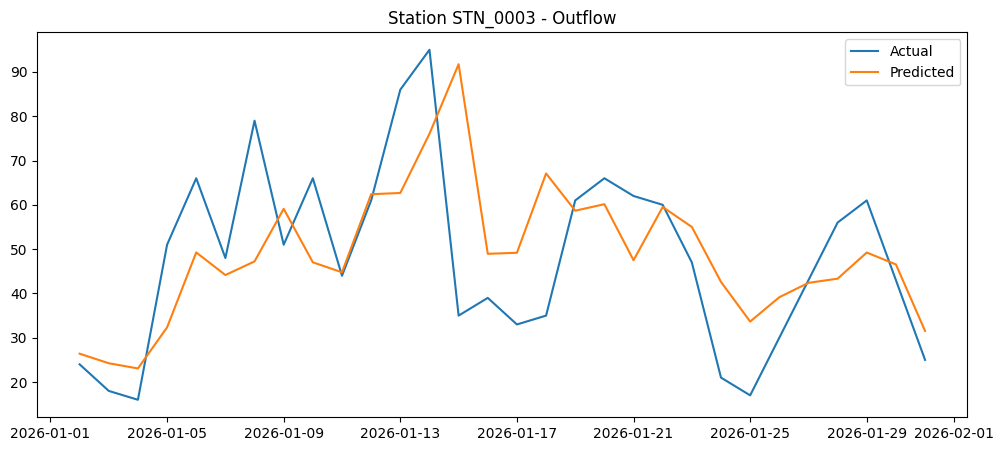

In [22]:
# train for outflow
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

results = []

# 🔷 1. Filter only STN_1030
station = "STN_0003"
station_df = pdf[pdf['station_id'] == station].copy()

# 🔷 2. Create features (OUTFLOW)
df_feat = create_features(station_df, 'outflow')

# 🔷 3. Check data size
if len(df_feat) < 50:
    print("Not enough data for modeling")
else:
    # 🔷 4. Train-test split
    split_date = df_feat.index.max() - pd.Timedelta(days=30)

    train = df_feat[df_feat.index <= split_date]
    test  = df_feat[df_feat.index > split_date]

    # 🔷 5. Features & target
    X_train = train.drop(columns=['outflow', 'inflow','station_id'])
    y_train = train['outflow']

    X_test = test.drop(columns=['outflow', 'inflow','station_id'])
    y_test = test['outflow']

    # 🔷 6. Train model
    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5
    )

    model.fit(X_train, y_train)

    # 🔷 7. Predict
    preds = model.predict(X_test)

    # 🔷 8. Metrics
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results.append({
        "station_id": station,
        "target": "outflow",
        "MAE": mae,
        "RMSE": rmse
    })

    print("MAE:", mae)
    print("RMSE:", rmse)

    # 🔷 9. Plot
    plt.figure()
    plt.plot(y_test.index, y_test, label='Actual')
    plt.plot(y_test.index, preds, label='Predicted')
    plt.title(f"Station {station} - Outflow")
    plt.legend()
    plt.show()

MAE: 8.182442665100098
RMSE: 10.955646915669577


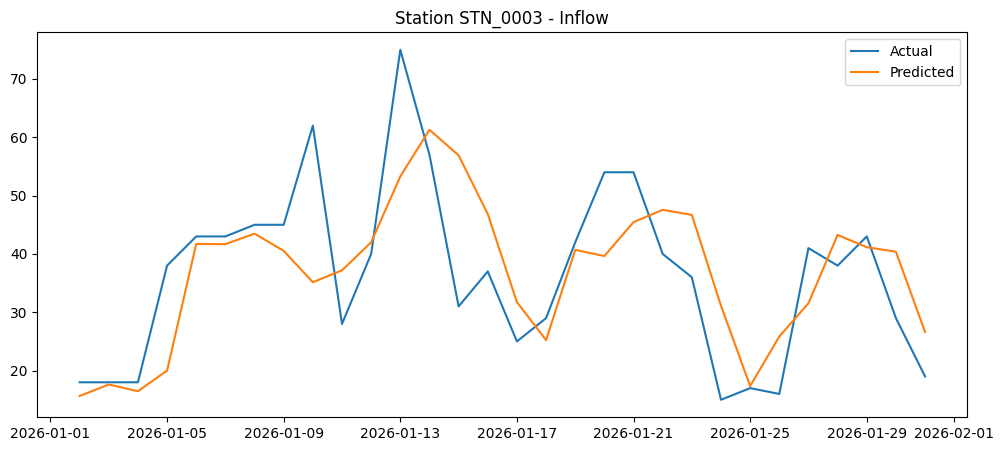

In [23]:
# train for inflow
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

results = []

# 🔷 1. Filter only STN_1030
station = "STN_0003"
station_df = pdf[pdf['station_id'] == station].copy()

# 🔷 2. Create features (OUTFLOW)
df_feat_inflow = create_features(station_df, 'inflow')

# 🔷 3. Check data size
if len(df_feat_inflow) < 50:
    print("Not enough data for modeling")
else:
    # 🔷 4. Train-test split
    split_date = df_feat_inflow.index.max() - pd.Timedelta(days=30)

    train = df_feat_inflow[df_feat_inflow.index <= split_date]
    test  = df_feat_inflow[df_feat_inflow.index > split_date]

    # 🔷 5. Features & target
    X_train = train.drop(columns=['outflow', 'inflow','station_id'])
    y_train = train['inflow']

    X_test = test.drop(columns=['outflow', 'inflow','station_id'])
    y_test = test['inflow']

    # 🔷 6. Train model
    model_inflow = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5
    )

    model_inflow.fit(X_train, y_train)

    # 🔷 7. Predict
    preds = model_inflow.predict(X_test)

    # 🔷 8. Metrics
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results.append({
        "station_id": station,
        "target": "inflow",
        "MAE": mae,
        "RMSE": rmse
    })

    print("MAE:", mae)
    print("RMSE:", rmse)

    # 🔷 9. Plot
    plt.figure()
    plt.plot(y_test.index, y_test, label='Actual')
    plt.plot(y_test.index, preds, label='Predicted')
    plt.title(f"Station {station} - Inflow")
    plt.legend()
    plt.show()

In [24]:
test

,station_id,outflow,inflow,day_of_week,month,week_of_year,is_weekend,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
date,,,,,,,,,,,,
2026-01-02,STN_0003,24,18,4,1,1,0,7.0,17.0,67.0,17.428571,7.849780
2026-01-03,STN_0003,18,18,5,1,1,1,18.0,17.0,49.0,17.571429,7.849780
2026-01-04,STN_0003,16,18,6,1,1,1,18.0,25.0,31.0,16.571429,7.161404
2026-01-05,STN_0003,51,38,0,1,2,0,18.0,8.0,42.0,20.857143,9.702724
2026-01-06,STN_0003,66,43,1,1,2,0,38.0,28.0,26.0,23.000000,12.727922
2026-01-07,STN_0003,48,43,2,1,2,0,43.0,19.0,17.0,26.428571,14.570028
2026-01-08,STN_0003,79,45,3,1,2,0,43.0,7.0,8.0,31.857143,13.133019
2026-01-09,STN_0003,51,45,4,1,2,0,45.0,18.0,17.0,35.714286,12.324965
2026-01-10,STN_0003,66,62,5,1,2,1,45.0,18.0,17.0,42.000000,12.987173


### explore the use case of arima model

In [25]:
from statsmodels.tsa.arima.model import ARIMA

# Use ORIGINAL time series (not df_feat)
station_df = station_df.sort_values('date').set_index('date')

ts = station_df['outflow'].asfreq('D').fillna(0)

# Train-test split
train = ts[:split_date]
test  = ts[split_date:]

# Fit ARIMA
model = ARIMA(train, order=(2,1,2))  # (p,d,q)
model_fit = model.fit()

# Forecast
preds = model_fit.forecast(steps=len(test))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


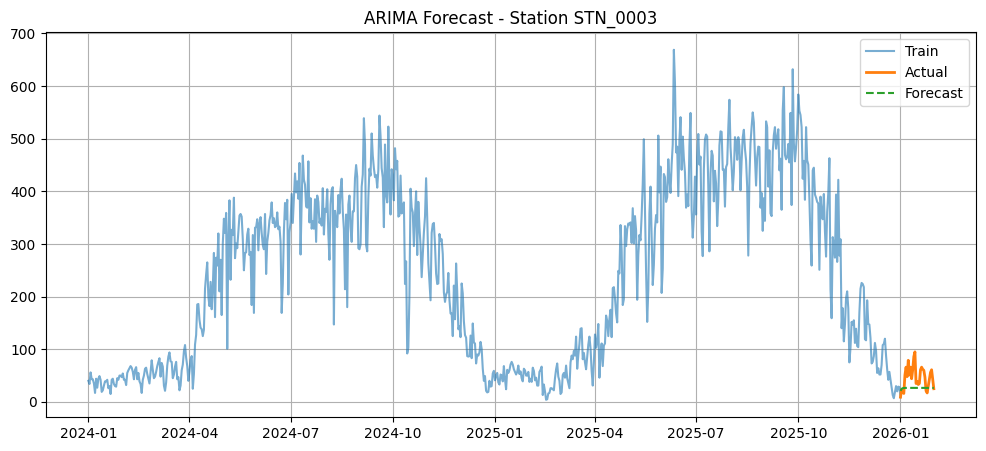

In [26]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label='Train', alpha=0.6)
plt.plot(test.index, test, label='Actual', linewidth=2)
plt.plot(test.index, preds, label='Forecast', linestyle='--')

plt.title(f"ARIMA Forecast - Station {station}")
plt.legend()
plt.grid(True)
plt.show()

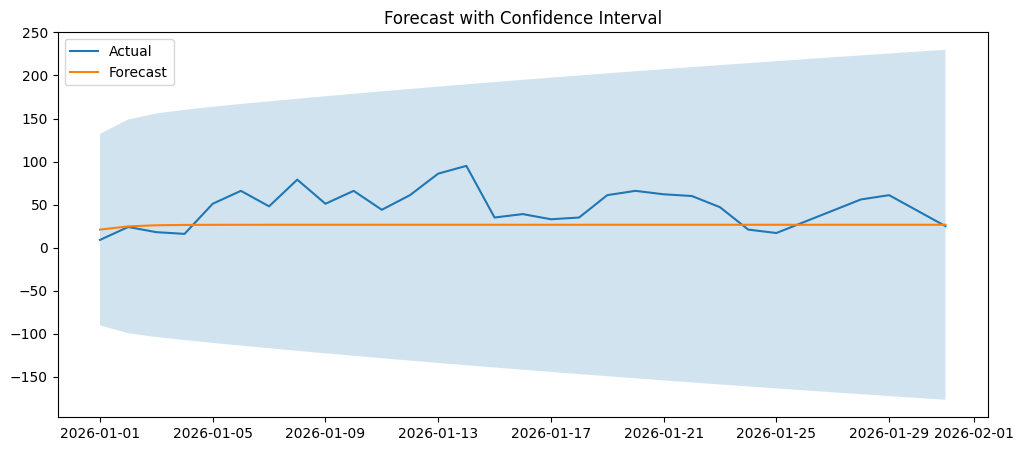

In [27]:
forecast = model_fit.get_forecast(steps=len(test))
preds = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(12,5))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, preds, label='Forecast')

plt.fill_between(
    test.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.2
)

plt.legend()
plt.title("Forecast with Confidence Interval")
plt.show()

In [28]:
mae = mean_absolute_error(test, preds)
rmse = np.sqrt(mean_squared_error(test, preds))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 23.484967184462437
RMSE: 29.02799963856111


### sarima

In [29]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(2,1,2),
    seasonal_order=(1,1,1,7)  # weekly seasonality
)

model_fit = model.fit()

preds = model_fit.forecast(steps=len(test))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


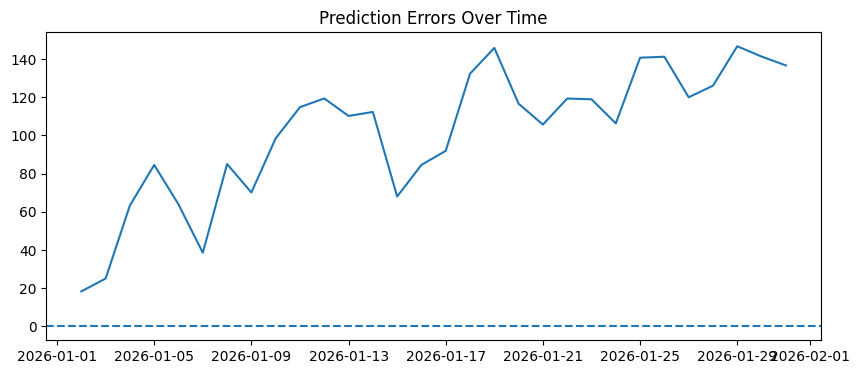

In [30]:
errors = test - preds

plt.figure(figsize=(10,4))
plt.plot(errors)
plt.axhline(0, linestyle='--')
plt.title("Prediction Errors Over Time")
plt.show()

### linear regression

MAE: 13.205902334406495
RMSE: 16.94131996764623


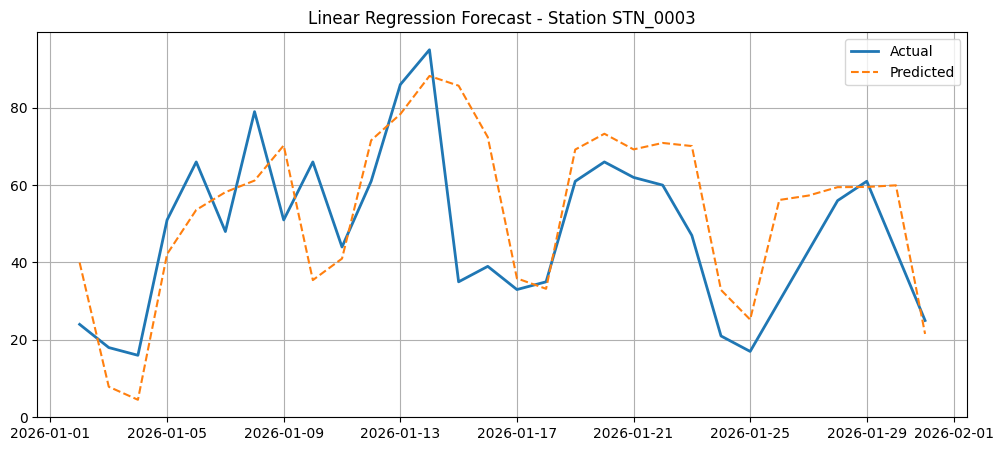

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

results = []

# 🔷 1. Filter only STN_1030
station = "STN_0003"
station_df = pdf[pdf['station_id'] == station].copy()

# 🔷 2. Create features
df_feat = create_features(station_df, 'outflow')

if len(df_feat) < 50:
    print("Not enough data")
else:
    # 🔷 3. Train-test split
    split_date = df_feat.index.max() - pd.Timedelta(days=30)

    train = df_feat[df_feat.index <= split_date]
    test  = df_feat[df_feat.index > split_date]

    # 🔷 4. Prepare X, y
    X_train = train.drop(columns=['outflow', 'inflow', 'station_id'])
    y_train = train['outflow']

    X_test = test.drop(columns=['outflow', 'inflow', 'station_id'])
    y_test = test['outflow']

    # 🔷 5. Keep only numeric (safety)
    X_train = X_train.select_dtypes(include=['int64', 'float64', 'bool'])
    X_test  = X_test.select_dtypes(include=['int64', 'float64', 'bool'])

    # 🔷 6. Train Linear Regression
    model = LinearRegression()
    model.fit(X_train, y_train)

    # 🔷 7. Predict
    preds = model.predict(X_test)

    # 🔷 8. Metrics
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    print("MAE:", mae)
    print("RMSE:", rmse)

    # 🔷 9. Smooth Plot (much nicer)
    plt.figure(figsize=(12,5))

    plt.plot(y_test.index, y_test, label='Actual', linewidth=2)
    plt.plot(y_test.index, preds, label='Predicted', linestyle='--')

    plt.title(f"Linear Regression Forecast - Station {station}")
    plt.legend()
    plt.grid(True)
    plt.show()

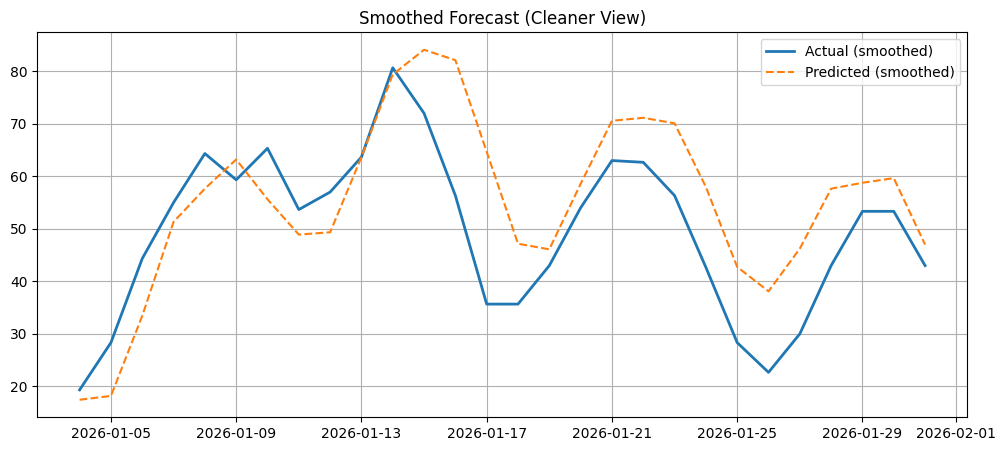

In [32]:
smooth_actual = y_test.rolling(3).mean()
smooth_preds  = pd.Series(preds, index=y_test.index).rolling(3).mean()

plt.figure(figsize=(12,5))

plt.plot(y_test.index, smooth_actual, label='Actual (smoothed)', linewidth=2)
plt.plot(y_test.index, smooth_preds, label='Predicted (smoothed)', linestyle='--')

plt.title("Smoothed Forecast (Cleaner View)")
plt.legend()
plt.grid(True)
plt.show()

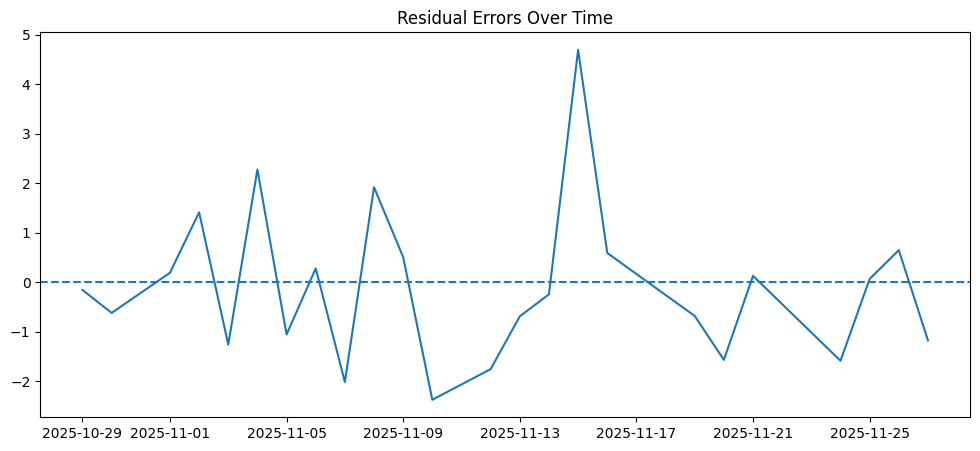

In [60]:
errors = y_test - preds

plt.figure(figsize=(12,5))
plt.plot(y_test.index, errors)
plt.axhline(0, linestyle='--')

plt.title("Residual Errors Over Time")
plt.show()

In [33]:
coef = pd.Series(model.coef_, index=X_train.columns)
print(coef.sort_values(ascending=False))

rolling_mean_7     0.738881
lag_1              0.203014
rolling_std_7      0.119821
lag_14             0.044405
lag_7              0.024702
week_of_year      -0.584106
is_weekend       -34.202960
dtype: float64


### comparison

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


              model        MAE       RMSE
0  LinearRegression  13.205902  16.941320
1           XGBoost  13.937272  17.828035
2            SARIMA  83.969704  88.414516


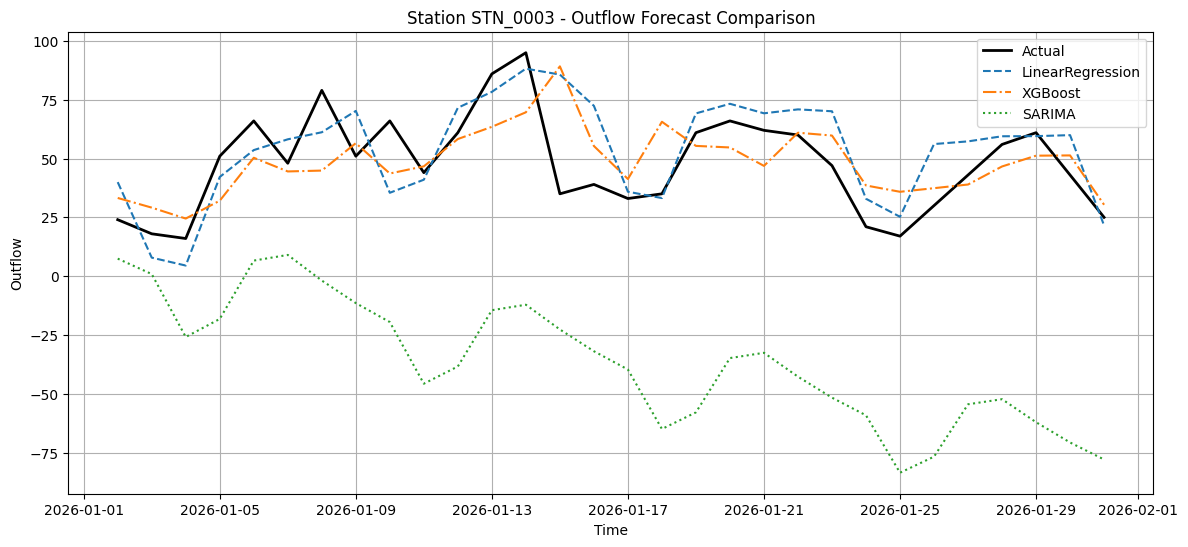

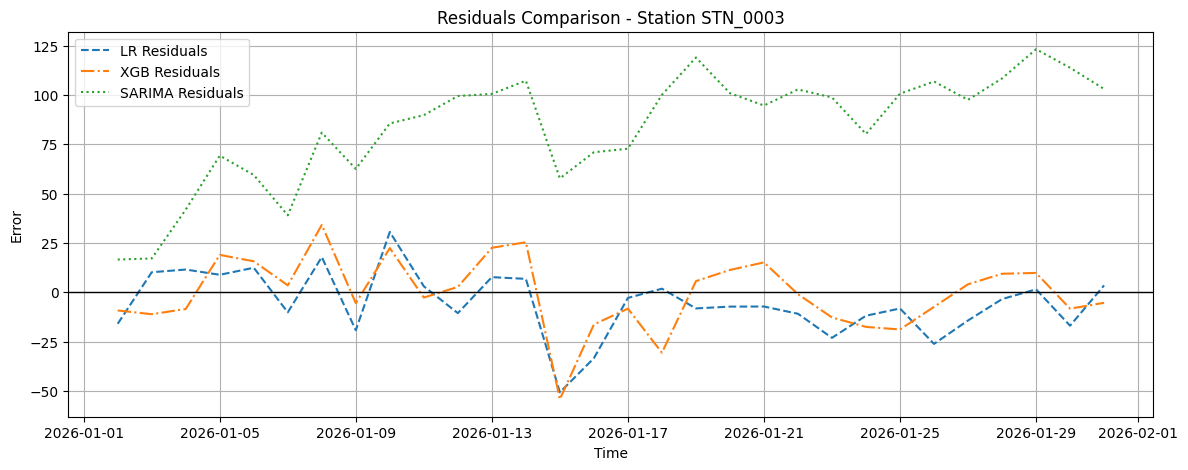

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

results = []

# 🔷 1. Filter station
station = "STN_0003"
station_df = pdf[pdf['station_id'] == station].copy()

# 🔷 2. Features
df_feat = create_features(station_df, 'outflow')

if len(df_feat) < 50:
    print("Not enough data")
else:
    # 🔷 3. Train-test split
    split_date = df_feat.index.max() - pd.Timedelta(days=30)

    train = df_feat[df_feat.index <= split_date]
    test  = df_feat[df_feat.index > split_date]

    X_train = train.drop(columns=['outflow','inflow','station_id'])
    y_train = train['outflow']
    X_test = test.drop(columns=['outflow','inflow','station_id'])
    y_test = test['outflow']

    # Keep only numeric
    X_train = X_train.select_dtypes(include=['int64','float64','bool'])
    X_test  = X_test.select_dtypes(include=['int64','float64','bool'])

    # 🔷 4. Linear Regression
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    lr_preds = lr_model.predict(X_test)
    lr_mae = mean_absolute_error(y_test, lr_preds)
    lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
    
    results.append({'model':'LinearRegression','MAE':lr_mae,'RMSE':lr_rmse})

    # 🔷 5. XGBoost
    xgb_model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )
    xgb_model.fit(X_train, y_train)
    xgb_preds = xgb_model.predict(X_test)
    xgb_mae = mean_absolute_error(y_test, xgb_preds)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
    
    results.append({'model':'XGBoost','MAE':xgb_mae,'RMSE':xgb_rmse})

    # 🔷 6. SARIMA (time series only)
    # auto-select seasonal order using AIC/BIC can be done but for demo use (1,1,1)x(1,0,1,7)
    sarima_model = SARIMAX(
        train['outflow'], 
        order=(1,1,1),
        seasonal_order=(1,0,1,7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_fit = sarima_model.fit(disp=False)
    # sarima_preds = sarima_fit.get_prediction(start=test.index[0], end=test.index[-1])
    # Predict using integer positions
    sarima_preds = sarima_fit.get_prediction(
        start=len(train),  # start right after training
        end=len(train) + len(test) - 1
    )
    sarima_preds_mean = sarima_preds.predicted_mean
    sarima_mae = mean_absolute_error(y_test, sarima_preds_mean)
    sarima_rmse = np.sqrt(mean_squared_error(y_test, sarima_preds_mean))
    
    results.append({'model':'SARIMA','MAE':sarima_mae,'RMSE':sarima_rmse})

    # 🔷 7. Metrics Table
    metrics_df = pd.DataFrame(results)
    print(metrics_df)

    # 🔷 8. Plot Actual vs Predicted (ALL MODELS)
    plt.figure(figsize=(14,6))
    plt.plot(y_test.index, y_test, label='Actual', linewidth=2, color='black')
    plt.plot(y_test.index, lr_preds, label='LinearRegression', linestyle='--')
    plt.plot(y_test.index, xgb_preds, label='XGBoost', linestyle='-.')
    plt.plot(y_test.index, sarima_preds_mean, label='SARIMA', linestyle=':')
    plt.title(f"Station {station} - Outflow Forecast Comparison")
    plt.xlabel("Time")
    plt.ylabel("Outflow")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 🔷 9. Plot Residuals (ALL MODELS)
    plt.figure(figsize=(14,5))
    plt.plot(y_test.index, y_test - lr_preds, label='LR Residuals', linestyle='--')
    plt.plot(y_test.index, y_test - xgb_preds, label='XGB Residuals', linestyle='-.')
    plt.plot(y_test.index, y_test - sarima_preds_mean, label='SARIMA Residuals', linestyle=':')
    plt.axhline(0, color='black', linewidth=1)
    plt.title(f"Residuals Comparison - Station {station}")
    plt.xlabel("Time")
    plt.ylabel("Error")
    plt.legend()
    plt.grid(True)
    plt.show()

### hourly window

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


48 48
               Model        MAE       RMSE
0  Linear Regression  18.435674  23.263673
1            XGBoost  14.761094  18.901262
2             SARIMA  38.626243  43.465927


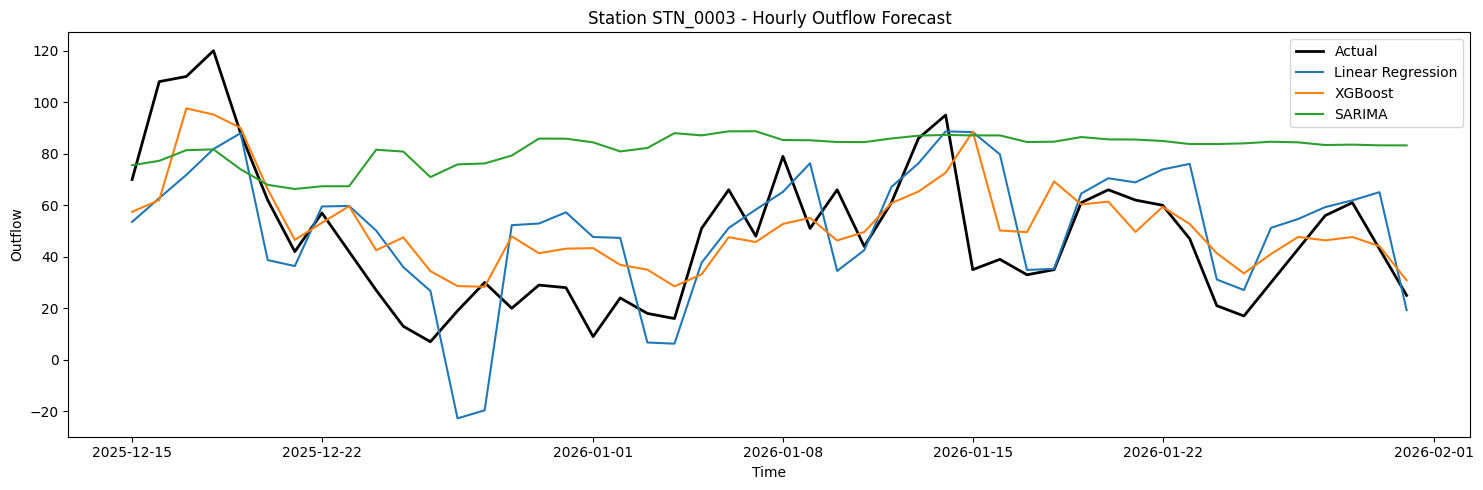

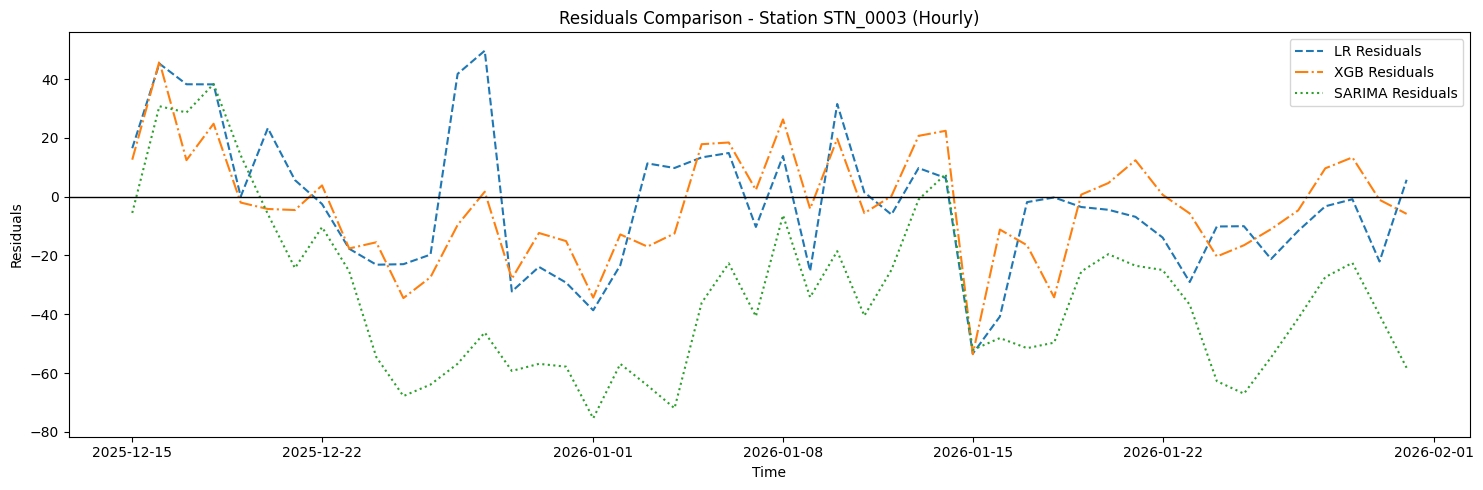

In [38]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

# =========================
# 1️⃣ Filter station & prepare features
# =========================
station = "STN_0003"
station_df = pdf[pdf['station_id'] == station].copy()

# Make sure index is datetime and sorted
station_df.index = pd.to_datetime(station_df.index)
station_df = station_df.sort_index()

# Create features for outflow (assuming your create_features handles lags)
df_feat = create_features(station_df, 'outflow')

# =========================
# 2️⃣ Train-test split (hourly)
# =========================
# Let's use last 48 hours (~2 days) as test
test_hours = 48
train = df_feat.iloc[:-test_hours]
test  = df_feat.iloc[-test_hours:]

# Features & target
X_train = train.drop(columns=['outflow', 'inflow','station_id'])
y_train = train['outflow']

X_test = test.drop(columns=['outflow', 'inflow','station_id'])
y_test = test['outflow']

# =========================
# 3️⃣ Linear Regression
# =========================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

# =========================
# 4️⃣ XGBoost
# =========================
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))

# =========================
# 5️⃣ SARIMA
# =========================
# Use last 7 days of hourly data to fit SARIMA for stability
sarima_train = train['outflow']
sarima_model = SARIMAX(
    sarima_train,
    order=(1,1,1),       # p,d,q
    seasonal_order=(1,0,1,24),  # daily seasonality (24h)
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)

# Forecast exact steps to match test window
sarima_forecast = sarima_fit.get_forecast(steps=len(y_test))
sarima_preds = sarima_forecast.predicted_mean.values  # convert to np.array to match y_test shape
sarima_mae = mean_absolute_error(y_test, sarima_preds)
sarima_rmse = np.sqrt(mean_squared_error(y_test, sarima_preds))
print(len(y_test), len(sarima_preds)) # Both should be 48

# =========================
# 6️⃣ Results summary
# =========================
results = pd.DataFrame({
    'Model': ['Linear Regression','XGBoost','SARIMA'],
    'MAE': [lr_mae, xgb_mae, sarima_mae],
    'RMSE': [lr_rmse, xgb_rmse, sarima_rmse]
})
print(results)

# =========================
# 7️⃣ Plot predictions
# =========================
plt.figure(figsize=(15,5))
plt.plot(y_test.index, y_test, label='Actual', color='black', linewidth=2)
plt.plot(y_test.index, lr_preds, label='Linear Regression')
plt.plot(y_test.index, xgb_preds, label='XGBoost')
plt.plot(y_test.index, sarima_preds, label='SARIMA')
plt.title(f"Station {station} - Hourly Outflow Forecast")
plt.xlabel("Time")
plt.ylabel("Outflow")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 8️⃣ Plot residuals
# =========================
plt.figure(figsize=(15,5))
plt.plot(y_test.index, y_test - lr_preds, label='LR Residuals', linestyle='--')
plt.plot(y_test.index, y_test - xgb_preds, label='XGB Residuals', linestyle='-.')
# plt.plot(y_test.index, y_test - sarima_preds, label='SARIMA Residuals', linestyle=':')
plt.plot(y_test.index, y_test.values - sarima_preds, label='SARIMA Residuals', linestyle=':')
plt.axhline(0, color='black', linewidth=1)
plt.title(f"Residuals Comparison - Station {station} (Hourly)")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
train

,station_id,outflow,inflow,day_of_week,month,week_of_year,is_weekend,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
date,,,,,,,,,,,,
2024-04-23,STN_1030,3,6,1,4,17,0,2.0,3.0,2.0,2.714286,1.976047
2024-04-24,STN_1030,5,4,2,4,17,0,3.0,2.0,0.0,3.142857,2.115701
2024-04-25,STN_1030,13,16,3,4,17,0,5.0,7.0,4.0,4.000000,4.163332
2024-04-26,STN_1030,7,6,4,4,17,0,13.0,1.0,4.0,4.857143,4.059087
2024-04-27,STN_1030,5,4,5,4,17,1,7.0,2.0,3.0,5.285714,3.860669
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-29,STN_1030,12,10,0,9,40,0,3.0,5.0,3.0,6.285714,3.638419
2025-09-30,STN_1030,2,3,1,9,40,0,12.0,3.0,6.0,6.142857,3.804759
2025-10-01,STN_1030,9,5,2,10,40,0,2.0,7.0,8.0,6.428571,3.952094


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

def compare_time_series_models(pdf, station_id, target='outflow', window='h'):
    # 1️⃣ Filter for station
    station_df = pdf[pdf['station_id'] == station_id].copy()

    # 1a️⃣ Ensure datetime index
    if not isinstance(station_df.index, pd.DatetimeIndex):
        if 'date' in station_df.columns:
            station_df['date'] = pd.to_datetime(station_df['date'])
            station_df.set_index('date', inplace=True)
        else:
            raise ValueError("DataFrame must have a datetime column to set as index")

    # 2️⃣ Resample to desired window
    station_df = station_df.resample(window).sum()

    # 3️⃣ Features & target (simplest: lag 1)
    df_feat = station_df.copy()
    df_feat['lag1'] = df_feat[target].shift(1)
    df_feat.dropna(inplace=True)

    # 4️⃣ Train-test split (last 30 periods)
    split_idx = -30
    train = df_feat.iloc[:split_idx]
    test = df_feat.iloc[split_idx:]

    X_train = train[['lag1']]
    y_train = train[target]
    X_test = test[['lag1']]
    y_test = test[target]

    # 5️⃣ Linear Regression
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    lr_preds = lr_model.predict(X_test)

    # 6️⃣ XGBoost
    xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3)
    xgb_model.fit(X_train, y_train)
    xgb_preds = xgb_model.predict(X_test)

    # 7️⃣ SARIMA (simplest: order 1,1,1)
    sarima_model = SARIMAX(train[target], order=(1,1,1), enforce_stationarity=False, enforce_invertibility=False)
    sarima_fit = sarima_model.fit(disp=False)
    sarima_preds = sarima_fit.get_prediction(start=test.index[0], end=test.index[-1])
    sarima_preds_mean = sarima_preds.predicted_mean

    # 8️⃣ Metrics
    results = pd.DataFrame({
        'Model': ['LinearRegression', 'XGBoost', 'SARIMA'],
        'MAE': [
            mean_absolute_error(y_test, lr_preds),
            mean_absolute_error(y_test, xgb_preds),
            mean_absolute_error(y_test, sarima_preds_mean)
        ],
        'RMSE': [
            np.sqrt(mean_squared_error(y_test, lr_preds)),
            np.sqrt(mean_squared_error(y_test, xgb_preds)),
            np.sqrt(mean_squared_error(y_test, sarima_preds_mean))
        ]
    })

    print(results)

    # 9️⃣ Plot actual vs predicted
    plt.figure(figsize=(14,6))
    plt.plot(y_test.index, y_test, label='Actual', color='black')
    plt.plot(y_test.index, lr_preds, label='LinearRegression', linestyle='--')
    plt.plot(y_test.index, xgb_preds, label='XGBoost', linestyle='-.')
    plt.plot(y_test.index, sarima_preds_mean, label='SARIMA', linestyle=':')
    plt.title(f"Station {station_id} - {target.capitalize()} Prediction ({window} window)")
    plt.legend()
    plt.show()

    # 10️⃣ Plot residuals
    plt.figure(figsize=(14,4))
    plt.plot(y_test.index, y_test - lr_preds, label='LR Residuals', linestyle='--')
    plt.plot(y_test.index, y_test - xgb_preds, label='XGB Residuals', linestyle='-.')
    plt.plot(y_test.index, y_test - sarima_preds_mean, label='SARIMA Residuals', linestyle=':')
    plt.axhline(0, color='black', linewidth=1)
    plt.title(f"Station {station_id} - Residuals ({window} window)")
    plt.legend()
    plt.show()

              Model        MAE       RMSE
0  LinearRegression  11.107183  11.842265
1           XGBoost  10.927446  11.822204
2            SARIMA   4.225606   8.794460


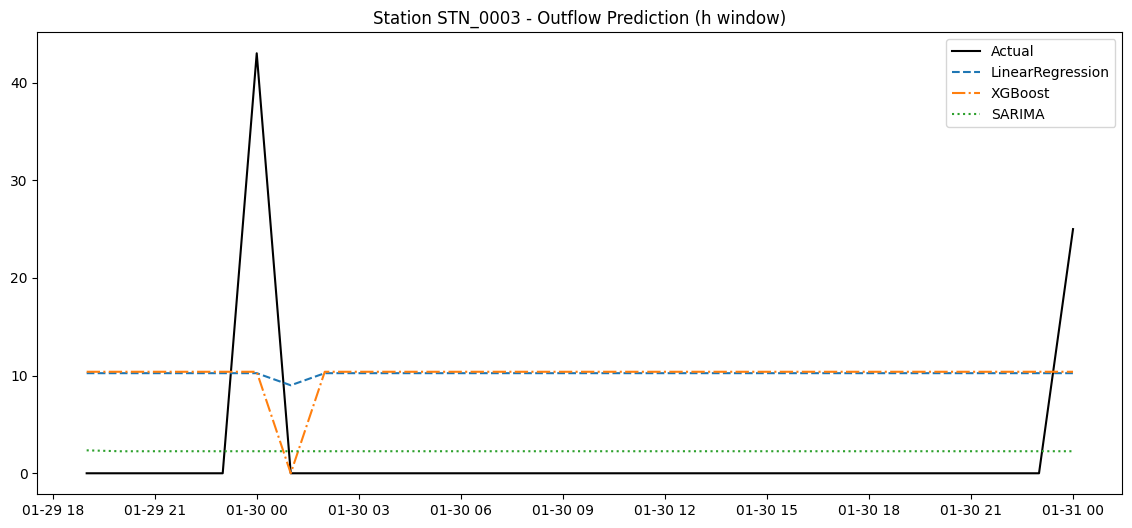

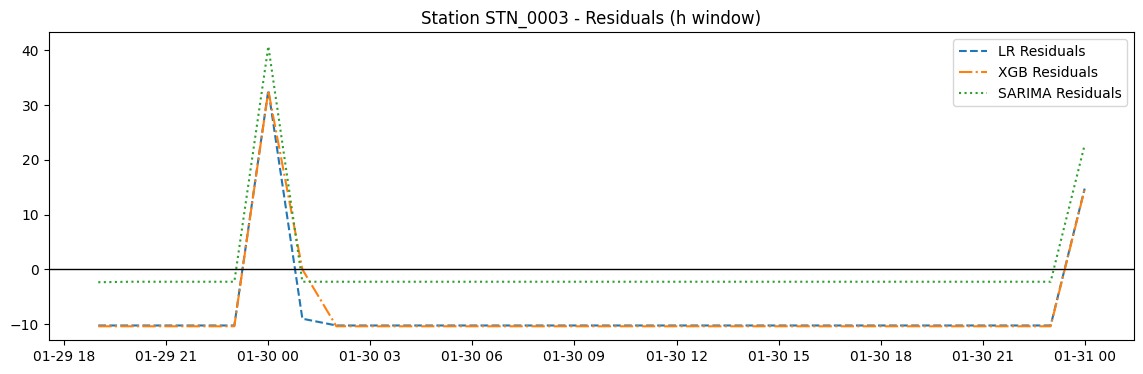

/var/folders/g1/d5m_mwrs139bdddffgxlr6kr0000gn/T/ipykernel_46877/2881631878.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  station_df = station_df.resample(window).sum()


ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by LinearRegression.

26/03/28 19:54:04 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 10578942 ms exceeds timeout 120000 ms
26/03/28 19:54:04 WARN SparkContext: Killing executors is not supported by current scheduler.
26/03/28 19:54:05 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint

In [ ]:
compare_time_series_models(pdf, station_id='STN_0003', target='outflow', window='h')  # hourly
compare_time_series_models(pdf, station_id='STN_0003', target='outflow', window='M')  # monthly

In [49]:
print(pdf.columns)  # check if you have a datetime column

Index(['station_id', 'date', 'outflow', 'inflow'], dtype='object')
